**Hidden Markov Model**

Paulo Yoshio Kuga

In this notebook, we are going to show how to train the HMM model with lissa.

In [1]:
#import libraries

import pandas as pd
from matplotlib import pyplot as plt
import numpy as np

import hmmlearn.hmm as hmm

import lissa as li

import json
from sklearn.mixture import GaussianMixture

In [2]:
#You also can read data without processing it always:

total_data = pd.read_csv("../data/totalProcessedData.csv",delimiter=",").fillna(0)
total_data["time"] = pd.to_datetime(total_data["time"])
total_data.set_index("time",inplace=True)

/tmp/ipykernel_220072/3032592086.py:3: DtypeWarning: Columns (14,15) have mixed types. Specify dtype option on import or set low_memory=False.
  total_data = pd.read_csv("../data/totalProcessedData.csv",delimiter=",").fillna(0)


Then, a list of properties is obtained through copy and paste of previous $list(entireData)$

In [3]:
with open("./dictionaries/new_headers.json") as dict:
    operational_headers = json.load(dict)["numerical_headers"]

pumpList = total_data["Well Run"].unique()

In [4]:
main_seed = 19971215
np.random.seed(main_seed)

total_data["Choke Closed"] = 1-total_data["Choke Opening"]
total_data["Radius"] = total_data[operational_headers].pow(2).sum(axis=1).pow(1/2)

X_train, train_length, X_test, test_length, model_data, total_length = li.Splitter(pumpList=pumpList,proportion=0.75,entireData=total_data)

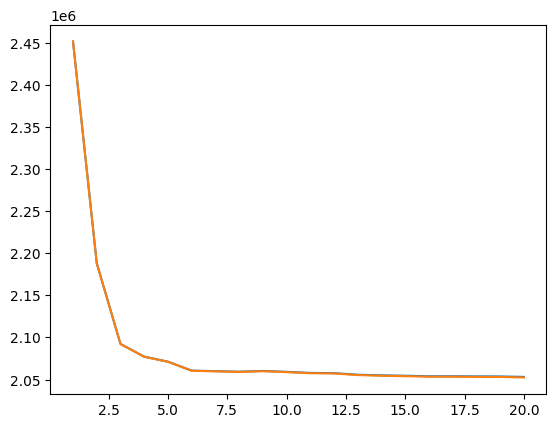

In [24]:
n_teste = 20

gmm_aic_array = np.zeros(20)
gmm_bic_array = np.zeros(20)

x = np.linspace(1,n_teste,n_teste)

radiusData = X_train["Radius"].loc[X_train["Well_down"]==0]
radius_data_np = li.check_data(radiusData)

for i in range(1,n_teste+1):
    model_gmm = GaussianMixture(n_components=i,random_state=main_seed)
    model_gmm.fit(radius_data_np)
    
    gmm_aic_array[i-1] = model_gmm.aic(radius_data_np)
    gmm_bic_array[i-1] = model_gmm.bic(radius_data_np)
    
plt.plot(x,np.array([gmm_bic_array,gmm_aic_array]).T)

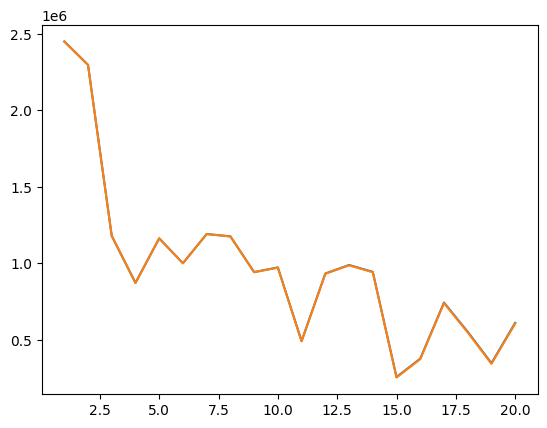

In [25]:
n_teste = 20

hmm_aic_array = np.zeros(20)
hmm_bic_array = np.zeros(20)

x = np.linspace(1,n_teste,n_teste)

X_train_np = li.check_data(X_train["Radius"])

for i in range(1,n_teste+1):
    
    model_hmm = hmm.GaussianHMM(
    n_components=i,
    random_state=main_seed,
    covariance_type="full",
    #params="st",
    init_params="st",
    algorithm="viterbi"
    )

    model_hmm.fit(X_train_np,train_length)
    
    hmm_aic_array[i-1] = model_hmm.aic(X_train_np,train_length)
    hmm_bic_array[i-1] = model_hmm.bic(X_train_np,train_length)

plt.plot(x,np.array([hmm_bic_array,hmm_aic_array]).T)

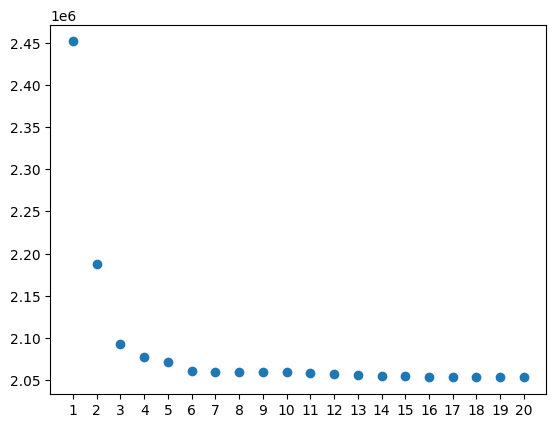

In [35]:


plt.scatter(x,gmm_bic_array)
plt.xticks(x);

In [ ]:
#pd.Series(gmm_bic_array).to_csv("./aicbic_analysis/gmm_bic.csv")